**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [23]:
## Clone the repository
!git clone https://github.com/Guillem-Are/sis1_group1.git

fatal: destination path 'sis1_group1' already exists and is not an empty directory.


In [24]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio
from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [25]:
filepath ="audio/Harp.wav"
ref, fs = load_audio(filepath)
plot_signals(ref,fs, startpoint, 2)



# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

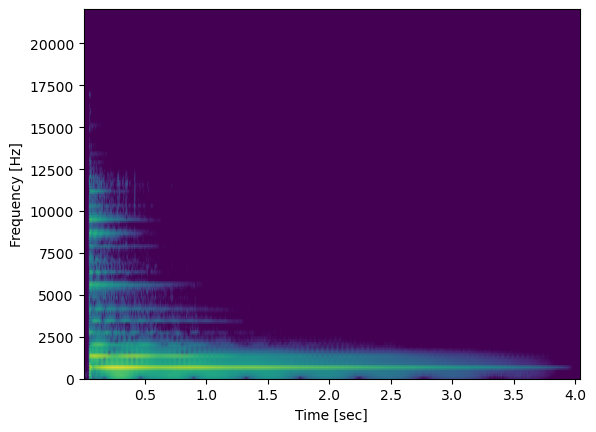

In [26]:
from scipy.signal import spectrogram
ff, tt, S= signal.spectrogram(ref,fs=fs)
plot_spectrogram(ff, tt,S)

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [27]:
from scipy.signal import spectrogram
plot_spectrum_at(ff, tt, S, 0.5)


1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


(0.0, 4000.0)

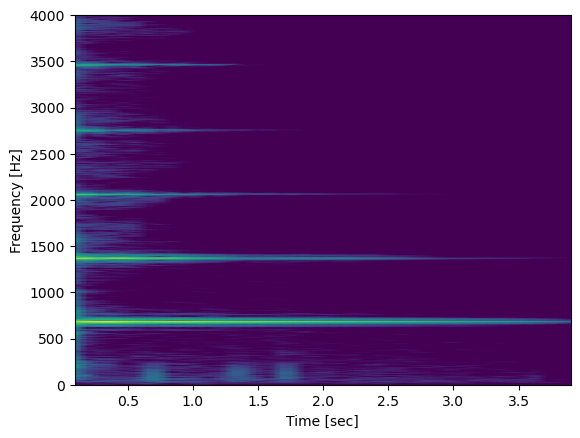

In [28]:
#plot_spectrogram(ff, tt, S_ref)
#plt.ylim([0,4000])
            #A bigger one to represent the stable part
ff, tt, S_ref= signal.spectrogram(ref,44100, nperseg=8192, noverlap=8192/2)   #We use the function
plot_spectrogram(ff, tt,S_ref)          #We plot it
plt.ylim([0,4000])



1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [29]:
time = 0.25
plot_spectrum_at(ff, tt, S_ref, time)


1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [30]:
weights = [1,0.2952121,0.04313676,0.02180361, 0.02591821, 0.02407627,0.003091922,0.04765071, 0.01077031,0.003986899,0.002941682]

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [31]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

In [32]:
t = np.arange(0, len(ref)/fs, 1.0/fs) 
f0 = 690
T = 1 / f0
phi = 49*np.pi/72 #previous lab
y_synt = synthesize(f0, phi, weights, t)

# Correct amplitude
A = 0.25155567 
y_synt *= A

plot_signals([ref, y_synt], fs, t_start=0.25, t_end = 0.25 + 10*T,  name=['Reference signal', 'Synthesis'])
ipd.Audio(y_synt, rate=fs)

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

In [33]:
# Write the code here
from scipy.signal import spectrogram
ff, tt, S_ref = spectrogram(ref, fs)
f_synt, t_synt, S_synt = spectrogram(y_synt, fs)
plot_spectrum_at(ff, tt, [S_ref, S_synt], 0.25)

Both spectrum signal lines look similar, especially in the beginning and then diverge. At the end they get closer again. The synthesized signal drops faster than the original. 

2.3. Compare the spectrograms of the two signals. What are the main differences?

Text(0.5, 1.0, 'Reference')

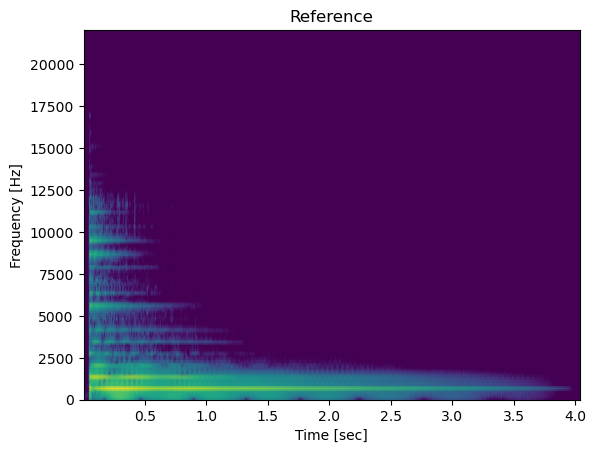

In [34]:
plot_spectrogram(ff, tt, S_ref)
plt.title("Reference")

Text(0.5, 1.0, 'Synthesized')

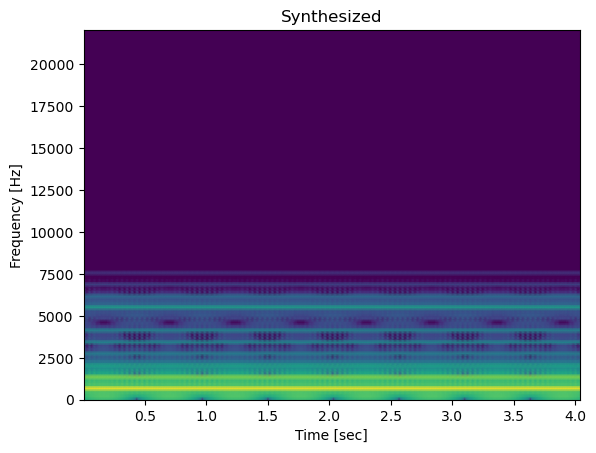

In [35]:
plot_spectrogram(f_synt, t_synt, S_synt)
plt.title("Synthesized")


We can observe that the synthesized signal appears as a cleaner version of the reference sound. its frequency remains constant and does not diminish over time. Additionally, we can see more clearly the the fundamental frequency at the yellow horizontal line around 690Hz in the second spectrogram.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [36]:
# Write the code here
ipd.Audio(ref, rate=fs)

In [37]:
ipd.Audio(y_synt, rate=fs)

One of the main differences between the reference and synthesized sounds is that the synthesized version doesn't have many of the harmonics present in the reference one, thus  it sounds less complex and more robotic. While both signals have the same note, the reference sound feels more natural like a harp meanwhile the synthesized one sounds cleaner but less realistic. This difference occurs because we cannot perfectly replicate the variations in frequency and texture created by external factors in the recording, such as ambient noise or the natural attack of the instrument, which contribute to the sound being so realistic.